# CS 363M — Wildlife strike: data cleaning and feature engineering

**Authors:** (your names)

This notebook:
- Summarizes **missing data** and **target** distribution
- **Explores** time patterns (year, month, hour) and a lat/lon sample
- **Cleans** data: drop ultra-sparse columns (≥ 80% missing) and free text; **exclude leakage**; **impute** (median for numeric, mode / `"Unknown"` for categorical)
- **Engineers** features: one calendar basis (`YEAR`, `MONTH`, `QUARTER`, `DOY`, `HOUR_IMPUTED`), **frequency** encodings, **one-hot** for medium-cardinality fields, **standardizes** `HEIGHT`, `SPEED`, `DISTANCE`, `HOUR_IMPUTED`
- Produces a numeric matrix `X` and `y` ready for e.g. `sklearn.ensemble.GradientBoostingClassifier` and nested CV (next step)

In [28]:
# Standard Headers
# You may add additional headers here if needed
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns # Is this one allowed??
import numpy as np

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# print your pandas version
pd.__version__ 

'3.0.1'

## 1. Load and target

The competition target is `INDICATED_DAMAGE` (0/1).

In [3]:
data = pd.read_csv("data/train.csv")

data.head()

C:\Users\T-Bone\AppData\Local\Temp\ipykernel_7620\1671173848.py:1: DtypeWarning: Columns (0: LATITUDE, 1: LONGITUDE, 2: AMO) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/train.csv")


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


# Data Exploration/Data Cleaning/Feature Engineering

In [ ]:
'''
Before even running any code, we decided to drop the following columns:

1. LONGITUDE/LATITUDE - We decided to use a broader feature of LOCATION, which is a categorical variable that indicates the general area where the property is located. This is because we believe that the specific longitude and latitude may not be as useful for predicting the target variable as the general location.
2. LUPDATE - This column contains the date of the last update for each property listing. We decided to drop this column because it may not be relevant for our analysis and could potentially introduce noise into our model.
3. TRANSFER - This column is an internal database flag. We decided to drop this column because it is not relevant for our analysis and could potentially introduce noise into our model.
4. PERSON - This column contains the name of the person who filed the report. We decided to drop this column because it is not relevant for our analysis.
5. INDEX_NR - This column contains an index number for each strike report. We decided to drop this column because it is not relevant for our analysis.
6. FLT - This column contains the flight number associated with each strike report. We decided to drop this column because it is not relevant for our analysis and could potentially introduce noise into our model.

We initially thought of dropping redundant columns such as INCIDENT_DATE and INCIDENT_MONTH/YEAR, but we decided to keep them to "merge" them to impute missing values for either column.
'''

'\nBefore even running any code, we decided to drop the following columns:\n\n1. LONGITUDE/LATITUDE - We decided to use a broader feature of LOCATION, which is a categorical variable that indicates the general area where the property is located. This is because we believe that the specific longitude and latitude may not be as useful for predicting the target variable as the general location.\n2. LUPDATE - This column contains the date of the last update for each property listing. We decided to drop this column because it may not be relevant for our analysis and could potentially introduce noise into our model.\n3. TRANSFER - This column is an internal database flag. We decided to drop this column because it is not relevant for our analysis and could potentially introduce noise into our model.\n4. PERSON - This column contains the name of the person who filed the report. We decided to drop this column because it is not relevant for our analysis.\n5. INDEX_NR - This column contains an in

### Finding the percentage of missing data per feature

In [5]:
# Calculate the percentage of missing data
missing_percentage = (data.isnull().sum() / len(data)) * 100

# Filter out columns that have 0 missing values, and sort them descending
missing_data = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Display the results
print("Percentage of Missing Data per Column:\n")
print(missing_data.round(2).astype(str) + ' %')

Percentage of Missing Data per Column:

BIRD_BAND_NUMBER    99.77 %
ENG_4_POS           98.94 %
ENROUTE_STATE       98.26 %
PRECIPITATION       96.35 %
ENG_3_POS           95.98 %
LOCATION            87.23 %
SPEED               69.04 %
NUM_SEEN            67.89 %
SKY                 53.01 %
FLT                 52.55 %
HEIGHT               50.2 %
TIME_OF_DAY         43.61 %
PHASE_OF_FLIGHT     39.38 %
REG                 38.73 %
AMO                 38.03 %
EMO                 36.84 %
TIME                35.57 %
DISTANCE            33.63 %
COMMENTS            33.56 %
ENG_2_POS           33.37 %
EMA                 33.34 %
AMA                 28.94 %
TYPE_ENG            28.58 %
ENG_1_POS           28.56 %
NUM_ENGS            28.55 %
AC_MASS             28.47 %
AC_CLASS            28.42 %
RUNWAY              24.61 %
LONGITUDE           13.26 %
LATITUDE            13.26 %
FAAREGION           13.26 %
STATE               13.26 %
REMARKS             11.49 %
SIZE                10.91 %
PERSON  

In [6]:
# Through this analysis, we decided to drop columns that have more than 85% missing data.

### Looking at each categorical feature's cardinality

In [7]:
# 1. Select only the categorical (text) columns
categorical_cols = data.select_dtypes(include=['object', 'category']).columns

# 2. Count the number of unique values for each categorical column
cardinality = data[categorical_cols].nunique().sort_values(ascending=False)

# 3. Create a clean, readable dataframe to display the results
cardinality_df = pd.DataFrame({
    'Column Name': cardinality.index, 
    'Unique Values': cardinality.values
})

print("Categorical Cardinality (Number of Unique Values per Column):\n")
print(cardinality_df.to_string(index=False))

C:\Users\T-Bone\AppData\Local\Temp\ipykernel_7620\2242176088.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object', 'category']).columns


Categorical Cardinality (Number of Unique Values per Column):

     Column Name  Unique Values
         REMARKS         250608
        COMMENTS         189613
             REG          44094
   INCIDENT_DATE          13113
             FLT          10649
        LOCATION           9230
         LUPDATE           4720
        LATITUDE           4157
       LONGITUDE           3912
         AIRPORT           2672
      AIRPORT_ID           2672
            TIME           1441
          RUNWAY           1362
      SPECIES_ID            933
         SPECIES            933
            OPID            624
        OPERATOR            616
        AIRCRAFT            615
BIRD_BAND_NUMBER            612
             AMO            118
             AMA             93
           STATE             67
   ENROUTE_STATE             58
          SOURCE             16
 PHASE_OF_FLIGHT             12
       FAAREGION             10
   PRECIPITATION             10
        TYPE_ENG              7
         

In [ ]:
# We decided to drop features with a large amount of unique values (> 15000) since they are likely to be less useful for our model and may introduce noise.

### Additionally we wanted to see whether each column had correct values

--- Top 15 Most Common 'NUM_SEEN' Values ---
NUM_SEEN
NaN              208546
1                 60295
10-Feb            30139
11-100             7221
More than 100       977
Name: count, dtype: int64


--- NUM_SEEN Summary Statistics ---
count    60295.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: NUM_SEEN, dtype: float64




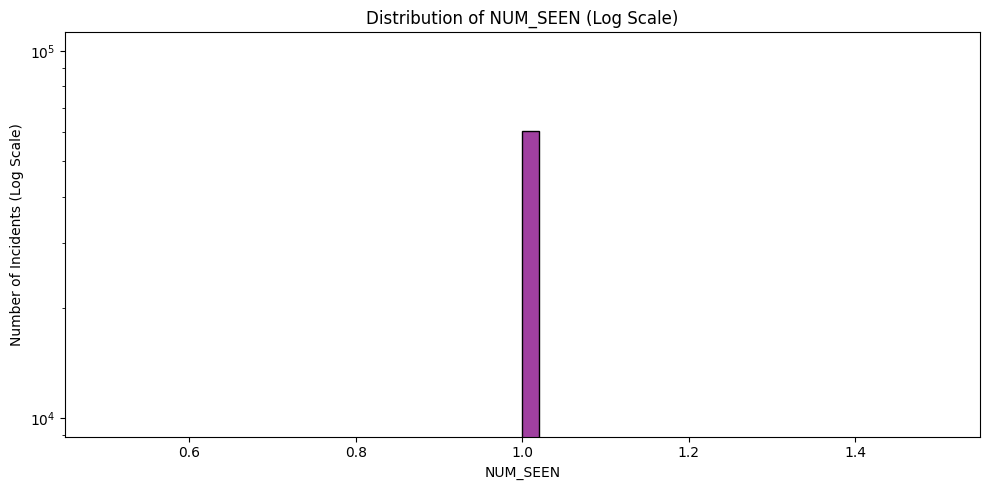

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def explore_column(df, column_name):
    print(f"--- Top 15 Most Common '{column_name}' Values ---")
    # 1. Print the top 15 most frequent values (including missing data/NaN)
    print(df[column_name].value_counts(dropna=False).head(15))
    print("\n")
    
    # 2. Check if the column is numeric (or can be treated as numeric)
    # This prevents the code from crashing if you pass in a text column like 'SPECIES'
    numeric_series = pd.to_numeric(df[column_name], errors='coerce')
    
    if numeric_series.notna().any():
        # Print summary statistics (min, max, mean, etc.)
        print(f"--- {column_name} Summary Statistics ---")
        print(numeric_series.describe())
        print("\n")
        
        # 3. Visualize the distribution (ignoring missing values for the graph)
        plt.figure(figsize=(10, 5))
        
        # Log scale histogram
        sns.histplot(numeric_series.dropna(), bins=50, kde=False, color='purple')
        plt.yscale('log') 
        plt.title(f'Distribution of {column_name} (Log Scale)')
        plt.xlabel(column_name)
        plt.ylabel('Number of Incidents (Log Scale)')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"--- Note: '{column_name}' is not numeric. Skipping statistics and histogram. ---")

# explore_column(data, 'SPEED')
# explore_column(data, 'SKY')
# explore_column(data, 'HEIGHT')
# explore_column(data, 'TIME_OF_DAY')
# explore_column(data, 'TIME')
# explore_column(data, 'PHASE_OF_FLIGHT')
# explore_column(data, 'AMO')
# explore_column(data, 'EMO')
# explore_column(data, 'DISTANCE')
# explore_column(data, 'ENG_2_POS')
# explore_column(data, 'EMA')
# explore_column(data, 'AMA')
# explore_column(data, 'TYPE_ENG')
# explore_column(data, 'ENG_1_POS')
# explore_column(data, 'NUM_ENGS')
# explore_column(data, 'AC_MASS')
# explore_column(data, 'AC_CLASS')
# explore_column(data, 'RUNWAY')
# explore_column(data, 'FAAREGION')
# explore_column(data, 'STATE')
# explore_column(data, 'SIZE')
# explore_column(data, 'NUM_SEEN')
# explore_column(data, 'NUM_STRUCK')

In [ ]:
'''
We decided to drop the following columns:

1. NUM_SEEN - This column had lots of dummy values being dates or random numbers such as 10-100.
2. NUM_STRUCK - This column had lots of dummy values being dates or random numbers such as 10-100.
'''

--- Analyzing TIME vs TIME_OF_DAY ---


C:\Users\T-Bone\AppData\Local\Temp\ipykernel_7620\1325776463.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_df['TIME_DATETIME'] = pd.to_datetime(temp_df['TIME'], errors='coerce')
C:\Users\T-Bone\AppData\Local\Temp\ipykernel_7620\1325776463.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='TIME_OF_DAY', y='HOUR', order=time_order,


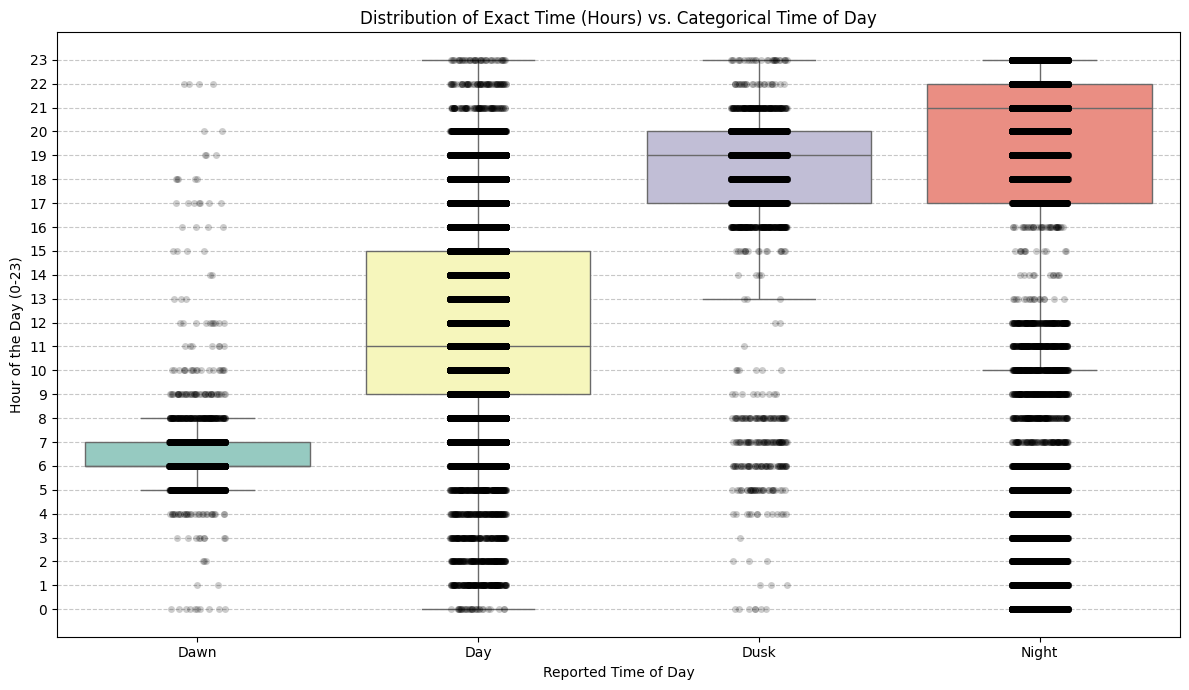

In [29]:
def plot_time_vs_time_of_day(df):
    print("--- Analyzing TIME vs TIME_OF_DAY ---")
    
    # Create a temporary dataframe so we don't accidentally alter the original
    temp_df = df[['TIME', 'TIME_OF_DAY']].copy()
    
    # Convert the TIME string into a datetime object, then extract just the hour (0-23)
    # errors='coerce' will turn any completely malformed text into a safe NaN (missing)
    temp_df['TIME_DATETIME'] = pd.to_datetime(temp_df['TIME'], errors='coerce')
    temp_df['HOUR'] = temp_df['TIME_DATETIME'].dt.hour
    
    # Drop rows where we don't have BOTH pieces of information for the graph
    temp_df = temp_df.dropna(subset=['HOUR', 'TIME_OF_DAY'])
    
    # --- Visualization ---
    plt.figure(figsize=(12, 7))
    
    # Order the categories logically
    time_order = ['Dawn', 'Day', 'Dusk', 'Night']
    
    # 1. Boxplot to show the median and middle 50% of the data
    sns.boxplot(data=temp_df, x='TIME_OF_DAY', y='HOUR', order=time_order, 
                palette='Set3', showfliers=False)
    
    # 2. Stripplot to show the actual individual strikes layered on top
    sns.stripplot(data=temp_df, x='TIME_OF_DAY', y='HOUR', order=time_order, 
                  color='black', alpha=0.2, jitter=True)
    
    plt.title('Distribution of Exact Time (Hours) vs. Categorical Time of Day')
    plt.xlabel('Reported Time of Day')
    plt.ylabel('Hour of the Day (0-23)')
    
    # Set y-axis to show every single hour for clear reading
    plt.yticks(range(0, 24))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

plot_time_vs_time_of_day(data)

In [30]:
# We noticed that the TIME_OF_DAY column does not correlate with the TIME column, which is a more specific feature. This suggests that the TIME_OF_DAY column may not be very useful for our model and could potentially introduce noise.


## 2. Drop not useful data
REMARKS, NUM_STRUCK, LOCATION, ENG_3_POS, BIRD_BAND_NUMBER, ENG_4_POS, ENROUTE_STATE, PRECIPITATION, COMMONS, TRANSFER, SOURCE, LUPDATE


In [41]:
cols_to_drop = [
    "REMARKS",
    "NUM_STRUCK",
    "LOCATION",
    "ENG_3_POS",
    "BIRD_BAND_NUMBER",
    "ENG_4_POS",
    "ENROUTE_STATE",
    "PRECIPITATION", # TRY THIS WITH AND WITHOUT THIS COLUMN
    "COMMENTS",
    "TRANSFER",
    "SOURCE",
    "LUPDATE", # last updated time
    "RUNWAY", # runway number
    "FLT", # flight number
    "AIRCRAFT", # name of the aircraft in text
    "INDEX_NR", # index number
    "REG", 
    "PERSON",
    "NUM_SEEN",
    "NUM_STRUCK"

]


df = data.drop(columns=cols_to_drop, errors="ignore")

df.head()

,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,STATE,...,DISTANCE,SKY,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,WARNED,SIZE,INDICATED_DAMAGE
0,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,PR,...,NaN,Some Cloud,UNKBS,Unknown bird - small,0,1,0,No,Small,0
1,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,FN,...,0.0,NaN,UNKBM,Unknown bird - medium,0,0,0,Unknown,Medium,0
2,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,KY,...,8.0,NaN,UNKBL,Unknown bird - large,0,0,0,No,Large,1
3,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,CA,...,0.0,NaN,NE120,Western gull,0,1,0,Unknown,Medium,0
4,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,HI,...,0.0,Some Cloud,R1101,American barn owl,0,0,0,No,Medium,0


## Merge the columns that are redudant

In [42]:
# Convert the incident date into structured temporal features.
incident_dt = pd.to_datetime(df["INCIDENT_DATE"], format="mixed", dayfirst=False, errors="coerce")
anchor = incident_dt.min()
df["INCIDENT_DATE"] = (incident_dt - anchor).dt.days

df["INCIDENT_MONTH"] = incident_dt.dt.month.fillna(-1).astype(int)
df["INCIDENT_DAYOFWEEK"] = incident_dt.dt.dayofweek.fillna(-1).astype(int)
df["INCIDENT_IS_WEEKEND"] = incident_dt.dt.dayofweek.isin([5, 6]).astype(int).fillna(0).astype(int)
df["INCIDENT_DAYOFYEAR"] = incident_dt.dt.dayofyear.fillna(-1).astype(int)

df = df.drop(columns=["INCIDENT_YEAR"], errors="ignore")

p = df["TIME"].astype(str).str.split(":", n=1, expand=True)
h = pd.to_numeric(p[0], errors="coerce")
if 1 in p.columns:
    m = pd.to_numeric(p[1], errors="coerce").fillna(0)
else:
    m = pd.Series(0, index=df.index)

df["TIME"] = (h * 60 + m).where(
    h.between(0, 23) & m.between(0, 59)
)
df["TIME_HOUR"] = h
df["TIME_MINUTE"] = m

df["TIME_SIN"] = np.sin(2 * np.pi * df["TIME"] / 1440)
df["TIME_COS"] = np.cos(2 * np.pi * df["TIME"] / 1440)

df = df.drop(columns=["TIME_OF_DAY"], errors="ignore")

# AIRPORT_ID, OPID, SPECIES_ID as the replacement for redundant columns
df = df.drop(columns=["AIRPORT"], errors="ignore")
df = df.drop(columns=["OPERATOR"], errors="ignore")
df = df.drop(columns=["SPECIES"], errors="ignore")


In [43]:
df.head()

,INCIDENT_DATE,INCIDENT_MONTH,TIME,AIRPORT_ID,LATITUDE,LONGITUDE,STATE,FAAREGION,OPID,AMA,...,SPEED,DISTANCE,SKY,SPECIES_ID,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,WARNED,SIZE,INDICATED_DAMAGE
0,1441,12,NaN,TJSJ,18.43942,-66.00183,PR,ASO,AAL,148,...,145.0,NaN,Some Cloud,UNKBS,0,1,0,No,Small,0
1,7335,2,300.0,WMKK,2.745578,101.709917,FN,FGN,FDX,583,...,NaN,0.0,NaN,UNKBM,0,0,0,Unknown,Medium,0
2,8163,5,120.0,KSDF,38.17439,-85.736,KY,ASO,UPS,04A,...,240.0,8.0,NaN,UNKBL,0,0,0,No,Large,1
3,4662,10,NaN,KLAX,33.94254,-118.40807,CA,AWP,UNK,NaN,...,NaN,0.0,NaN,NE120,0,1,0,Unknown,Medium,0
4,2589,2,NaN,PHLI,21.97598,-159.33896,HI,AWP,1AAH,148,...,135.0,0.0,Some Cloud,R1101,0,0,0,No,Medium,0


## Impute the data

In [44]:
# numeric values are left as missing so we can impute using training data only.
# categorical missing values are mapped to an explicit "Unknown" bucket.
for c in df.select_dtypes(include=["str", "object", "category"]).columns:
    df[c] = df[c].fillna("Unknown")


## Encode the data

In [45]:
# y = target; all other columns = features
TARGET = "INDICATED_DAMAGE"
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET], errors="ignore")

# integer codes for all text / object columns (fit on train only)
text_cols = list(X.select_dtypes(include=["str", "object", "string", "category"]).columns)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()

# Normalize text columns to a stable Unknown category.
def _as_cat_str(ser: pd.Series) -> pd.Series:
    s = ser.map(lambda v: "Unknown" if (v is None or (isinstance(v, float) and np.isnan(v)) or pd.isna(v)) else v)
    s = s.astype("string[python]").astype(str)
    return s.replace({"nan": "Unknown", "None": "Unknown", "<NA>": "Unknown", "": "Unknown"})

if text_cols:
    for c in text_cols:
        X_train[c] = _as_cat_str(X_train[c])
        X_test[c] = _as_cat_str(X_test[c])

    high_card_threshold = 30
    high_card_cols = [c for c in text_cols if X_train[c].nunique(dropna=False) > high_card_threshold]
    low_card_cols = [c for c in text_cols if X_train[c].nunique(dropna=False) <= high_card_threshold]

    # Frequency encoding for high-cardinality categorical features.
    for c in high_card_cols:
        freq = X_train[c].value_counts(normalize=True)
        X_train[c] = X_train[c].map(freq).fillna(0.0)
        X_test[c] = X_test[c].map(freq).fillna(0.0)

    # One-hot encode low-cardinality categorical features.
    if low_card_cols:
        ohe = OneHotEncoder(sparse=False, handle_unknown="ignore")
        ohe.fit(X_train[low_card_cols])
        ohe_train = pd.DataFrame(
            ohe.transform(X_train[low_card_cols]),
            columns=ohe.get_feature_names_out(low_card_cols),
            index=X_train.index,
        )
        ohe_test = pd.DataFrame(
            ohe.transform(X_test[low_card_cols]),
            columns=ohe.get_feature_names_out(low_card_cols),
            index=X_test.index,
        )
        X_train = X_train.drop(columns=low_card_cols).join(ohe_train)
        X_test = X_test.drop(columns=low_card_cols).join(ohe_test)

# any leftover object / str -> numeric
for c in X_train.columns:
    if X_train[c].dtype == "object" or str(X_train[c].dtype).startswith("string"):
        X_train[c] = pd.to_numeric(X_train[c], errors="coerce")
        X_test[c] = pd.to_numeric(X_test[c], errors="coerce")

# Add missing-value indicators for numeric columns where missingness may be informative.
for c in X_train.columns:
    if X_train[c].isna().any():
        X_train[f"{c}_MISSING"] = X_train[c].isna().astype(int)
        X_test[f"{c}_MISSING"] = X_test[c].isna().astype(int)

# Impute numeric missing values with training medians.
num_cols = X_train.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy="median")
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

X_train = X_train.astype(float)
X_test = X_test.astype(float)

print("X_train", X_train.shape, "| X_test", X_test.shape, "| text columns:", text_cols)


X_train (245742, 30) | X_test (61436, 30) | label-encoded: ['AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'STATE', 'FAAREGION', 'OPID', 'AMA', 'AMO', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SKY', 'SPECIES_ID', 'WARNED', 'SIZE']


In [60]:
X.head(10)

,INCIDENT_DATE,INCIDENT_MONTH,TIME,AIRPORT_ID,LATITUDE,LONGITUDE,STATE,FAAREGION,OPID,AMA,...,HEIGHT,SPEED,DISTANCE,SKY,SPECIES_ID,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,WARNED,SIZE
0,1441,12,-1.0,TJSJ,18.43942,-66.00183,PR,ASO,AAL,148,...,300.0,145.0,-1.0,Some Cloud,UNKBS,0,1,0,No,Small
1,7335,2,300.0,WMKK,2.745578,101.709917,FN,FGN,FDX,583,...,50.0,-1.0,0.0,Unknown,UNKBM,0,0,0,Unknown,Medium
2,8163,5,120.0,KSDF,38.17439,-85.736,KY,ASO,UPS,04A,...,3500.0,240.0,8.0,Unknown,UNKBL,0,0,0,No,Large
3,4662,10,-1.0,KLAX,33.94254,-118.40807,CA,AWP,UNK,Unknown,...,-1.0,-1.0,0.0,Unknown,NE120,0,1,0,Unknown,Medium
4,2589,2,-1.0,PHLI,21.97598,-159.33896,HI,AWP,1AAH,148,...,0.0,135.0,0.0,Some Cloud,R1101,0,0,0,No,Medium
5,11165,7,538.0,RCTP,25.077731,121.232822,FN,FGN,FDX,148,...,0.0,110.0,0.0,No Cloud,UNKBS,0,0,0,Unknown,Small
6,7474,6,432.0,KMSY,29.99339,-90.25803,LA,ASW,JBU,04A,...,0.0,-1.0,0.0,No Cloud,UNKBS,0,0,0,Yes,Small
7,6074,8,460.0,KSBN,41.70895,-86.31847,IN,AGL,FLG*,188,...,0.0,-1.0,0.0,No Cloud,O2205,0,1,0,No,Small
8,4628,9,-1.0,KJFK,40.63975,-73.77893,NY,AEA,AAL,148,...,0.0,-1.0,0.0,Unknown,K2001,0,1,0,Unknown,Large
9,10154,10,1238.0,KEWR,40.6925,-74.16866,NJ,AEA,UAL,04A,...,0.0,-1.0,0.0,No Cloud,R2203,0,1,0,Unknown,Large


Train a model

In [59]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

# Use nested cross-validation for model selection and evaluation.
# Outer CV estimates generalization, inner CV selects the best hyperparameters.
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

param_grid = {
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_leaf_nodes": [15, 31, 63, 127],
    "max_iter": [100, 200, 300, 500],
    "l2_regularization": [0.01, 0.05, 0.1, 0.2],
}

base_clf = HistGradientBoostingClassifier(
    class_weight="balanced",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
)

inner_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring="average_precision",
    cv=inner_cv,
    n_jobs=1,
    refit=True,
    verbose=1,
)

print("Running nested CV with inner grid search and outer evaluation. This may take time.")
nested_scores = cross_val_score(
    inner_search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring="average_precision",
    n_jobs=-1,
)
print(f"Nested CV PR-AUC: {nested_scores.mean():.4f} +/- {nested_scores.std():.4f}")

# Refit the best model on the full training set for final evaluation.
inner_search.fit(X_train, y_train)
print('Best hyperparameters on full training data:', inner_search.best_params_)
print('Best inner CV average precision:', inner_search.best_score_)

final_clf = inner_search.best_estimator_

p = final_clf.predict_proba(X_test)[:, 1]
print('\n=== Test Set Performance ===')
print('ROC-AUC:', roc_auc_score(y_test, p))
print('PR-AUC:', average_precision_score(y_test, p))
print(classification_report(y_test, final_clf.predict(X_test), digits=4))


ROC-AUC: 0.9047264948356852
PR-AUC: 0.5061127459394116
              precision    recall  f1-score   support

           0     0.9808    0.8748    0.9248     57531
           1     0.2884    0.7475    0.4162      3905

    accuracy                         0.8667     61436
   macro avg     0.6346    0.8111    0.6705     61436
weighted avg     0.9368    0.8667    0.8924     61436



## create a submission file

In [61]:
import subprocess
import sys

subprocess.check_call(
    [
        sys.executable,
        "scripts/make_submission.py",
        "--train", "train.csv",
        "--test", "test.csv",
        "--out", "submission.csv",
    ],
)
print("Wrote submission.csv")

/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/noorali/dev/ml-1-project/scripts/make_submission.py': [Errno 2] No such file or directory


CalledProcessError: Command '['/Users/noorali/dev/ml-1-project/.venv/bin/python', 'scripts/make_submission.py', '--train', 'train.csv', '--test', 'test.csv', '--out', 'submission.csv']' returned non-zero exit status 2.

/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/noorali/dev/ml-1-project/scripts/make_submission.py': [Errno 2] No such file or directory


CalledProcessError: Command '['/Users/noorali/dev/ml-1-project/.venv/bin/python', 'scripts/make_submission.py', '--train', 'train.csv', '--test', 'test.csv', '--out', 'submission.csv']' returned non-zero exit status 2.